# 06 · Bonus: GAN híbrida clásico-cuántica

## Aviso previo

Esto **no lo pide el enunciado**. Los tres modelos generativos obligatorios tienen que ser de las familias vistas en
clase y están en el notebook 03. Esto es un modelo generativo **extra**, etiquetado como tal, y se ejecuta
íntegramente en **simulador**: no hay hardware cuántico en ningún punto.

## Qué es cuántico exactamente

El núcleo del generador es un **circuito cuántico variacional** simulado en `default.qubit` de PennyLane:

1. el ruido latente se **codifica en ángulos** de rotación `RY`, uno por qubit (*angle encoding*);
2. se entrelaza con `StronglyEntanglingLayers`, tres capas de rotaciones parametrizadas y puertas CNOT;
3. se lee el **valor esperado de Pauli-Z** de cada qubit, obteniendo 8 números;
4. un decoder lineal diminuto los lleva al espacio de datos.

Los parámetros del circuito se entrenan por descenso de gradiente **a través del simulador** (`diff_method="backprop"`),
junto con el decoder y contra un discriminador clásico. Es decir, la parte cuántica es **entrenable de verdad**, no
un mapa de características fijo.

## Cómo hacemos que la comparación signifique algo

Comparar un circuito de 8 qubits contra la GAN densa del notebook 03, que tiene más de un millón de parámetros, no
diría nada. Así que:

- **mismo espacio**: los dos generadores viven en un espacio **PCA de 16 dimensiones**. Un circuito que lee 8
  valores esperados no puede direccionar 1380 dimensiones de salida sin un decoder clásico grande que haría todo el
  trabajo real y dejaría la etiqueta "cuántico" en pura decoración;
- **mismo presupuesto de parámetros**: el gemelo clásico es un MLP cuyo número de parámetros se ajusta **exactamente**
  al del generador cuántico;
- **todo lo demás idéntico**: mismo discriminador, mismo optimizador, misma dimensión latente, mismas épocas, mismas
  semillas, misma distribución de ruido latente (uniforme en `[-π, π]`, que son ángulos válidos de rotación).

Con eso, cualquier diferencia es atribuible a la **familia del generador** y no a su capacidad.

**No damos por hecho que gane el cuántico.** Con 8 qubits en un simulador no hay ninguna razón teórica para que lo
haga, y el resultado honesto esperable es un empate en el mejor de los casos. Lo interesante es medirlo bien.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

In [2]:
from src import config, data, plots
from src.generators import quantum

split, returns, extras = data.load_problem()
X_min = split.X_train[split.y_train == 1]

qml = quantum.ensure_pennylane()
print(f"PennyLane {qml.__version__}")
print(f"Qubits: {config.QUANTUM_QUBITS} | capas: {config.QUANTUM_LAYERS} | "
      f"espacio PCA: {config.QUANTUM_COMPONENTS} dims | épocas: {config.QUANTUM_EPOCHS}")

PennyLane 0.45.1
Qubits: 8 | capas: 3 | espacio PCA: 16 dims | épocas: 600


## El circuito

Lo dibujamos antes de entrenar, porque un diagrama dice más que la descripción.

In [3]:
import numpy as _np

n_q, n_l = config.QUANTUM_QUBITS, config.QUANTUM_LAYERS
dev = qml.device("default.qubit", wires=n_q)

@qml.qnode(dev)
def circuito(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_q), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(n_q))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_q)]

print(qml.draw(circuito, show_matrices=False, level="device")(
    _np.zeros(n_q), _np.zeros((n_l, n_q, 3))
))
print(f"\nParámetros variacionales del circuito: {n_l * n_q * 3}")

0: ──RY(0.00)──Rot(0.00,0.00,0.00)─╭●───────────────────╭X──Rot(0.00,0.00,0.00)─╭●──────────── ···
1: ──RY(0.00)──Rot(0.00,0.00,0.00)─╰X─╭●────────────────│───Rot(0.00,0.00,0.00)─│──╭●───────── ···
2: ──RY(0.00)──Rot(0.00,0.00,0.00)────╰X─╭●─────────────│───Rot(0.00,0.00,0.00)─╰X─│──╭●────── ···
3: ──RY(0.00)──Rot(0.00,0.00,0.00)───────╰X─╭●──────────│───Rot(0.00,0.00,0.00)────╰X─│──╭●─── ···
4: ──RY(0.00)──Rot(0.00,0.00,0.00)──────────╰X─╭●───────│───Rot(0.00,0.00,0.00)───────╰X─│──╭● ···
5: ──RY(0.00)──Rot(0.00,0.00,0.00)─────────────╰X─╭●────│───Rot(0.00,0.00,0.00)──────────╰X─│─ ···
6: ──RY(0.00)──Rot(0.00,0.00,0.00)────────────────╰X─╭●─│───Rot(0.00,0.00,0.00)─────────────╰X ···
7: ──RY(0.00)──Rot(0.00,0.00,0.00)───────────────────╰X─╰●──Rot(0.00,0.00,0.00)─────────────── ···

0: ··· ────╭X──Rot(0.00,0.00,0.00)──────────────────────╭●─────────────╭X───────┤  <Z>
1: ··· ────│──╭X────────────────────Rot(0.00,0.00,0.00)─│──╭●──────────│──╭X────┤  <Z>
2: ··· ────│──│──────────────────

## Entrenamiento de los dos generadores

El cuántico y su gemelo clásico equiparado, en las mismas condiciones.

In [4]:
import time
from src.representation import WindowRepresentation

rep16 = WindowRepresentation(n_components=config.QUANTUM_COMPONENTS, seed=0).fit(split.X_train)
print(f"Espacio compartido: {rep16.name} ({rep16.dim} dims), "
      f"error de reconstrucción {rep16.reconstruction_error(split.X_test):.5f}")

modelos, historias, sinteticos = {}, {}, {}
for cls in (quantum.QuantumGANGenerator, quantum.MatchedClassicalGANGenerator):
    t0 = time.time()
    g = cls(seed=0, representation=rep16).fit(X_min)
    sinteticos[g.name] = g.sample(2000)
    historias[g.name] = g.history
    modelos[g.name] = g
    g.save_history()
    print(f"{g.label:45s} {g.n_params_:5d} parámetros  {time.time()-t0:6.1f}s")

Espacio compartido: pca16 (16 dims), error de reconstrucción 0.01101


GAN híbrida cuántica (VQC)                      216 parámetros    45.1s


GAN clásica equiparada en parámetros            216 parámetros     1.3s


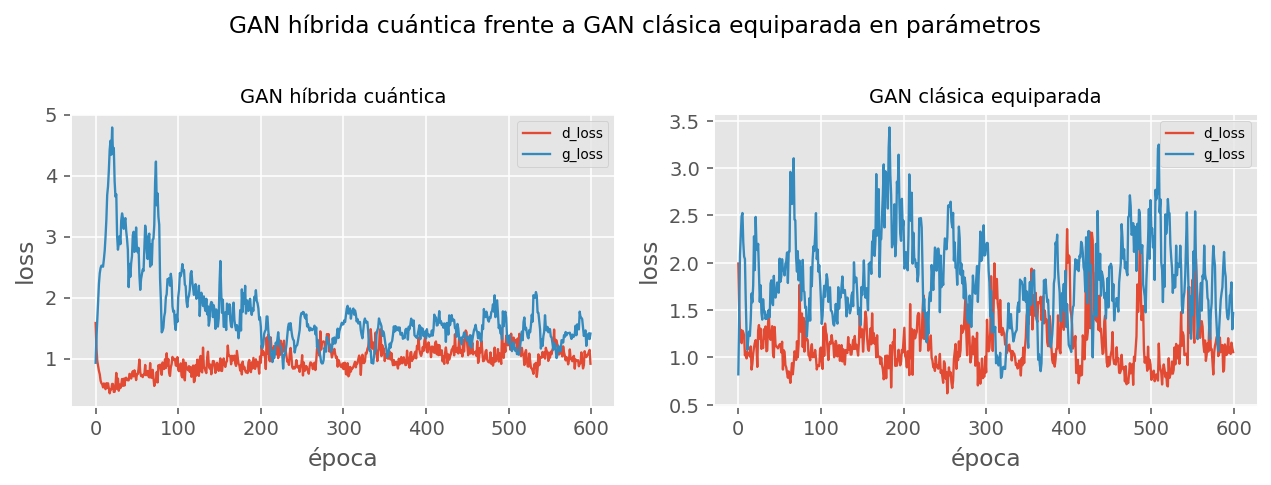

In [5]:
fig = plots.plot_loss_curves(
    historias, name="06_curvas_cuantico",
    title="GAN híbrida cuántica frente a GAN clásica equiparada en parámetros",
)
display(Image(str(fig)))

## Calidad de los datos generados

Las mismas estadísticas del notebook 03, para poder comparar en los mismos términos.

In [6]:
from src.experiments import _quality_stats

filas = {"REAL": _quality_stats(X_min)}
filas["PCA-16 (techo alcanzable)"] = _quality_stats(rep16.inverse_transform(rep16.transform(X_min)))
for nombre, Xs in sinteticos.items():
    filas[plots.GEN_LABELS.get(nombre, nombre)] = _quality_stats(Xs)
display(pd.DataFrame(filas).T.round(4))

,std,vol_cartera,corr_media,kurtosis,max_abs
REAL,0.0262,0.0147,0.4004,47.2948,0.5483
PCA-16 (techo alcanzable),0.0105,0.0086,0.9713,10.8266,0.1084
GAN híbrida cuántica,0.0078,0.0070,0.9711,4.8906,0.0595
GAN clásica equiparada,0.0122,0.0114,0.9685,4.6749,0.0883


La fila **PCA-16** es la clave para interpretar el resto: es lo mejor que **cualquier** generador podría conseguir
en este espacio, porque es el resultado de proyectar los datos reales a 16 dimensiones y volver. Todo lo que se
pierde ahí no es culpa del generador, ni del cuántico ni del clásico. Como vimos en el notebook 01, los retornos
diarios no se comprimen, así que 16 dimensiones son muy pocas y ese techo es bajo.

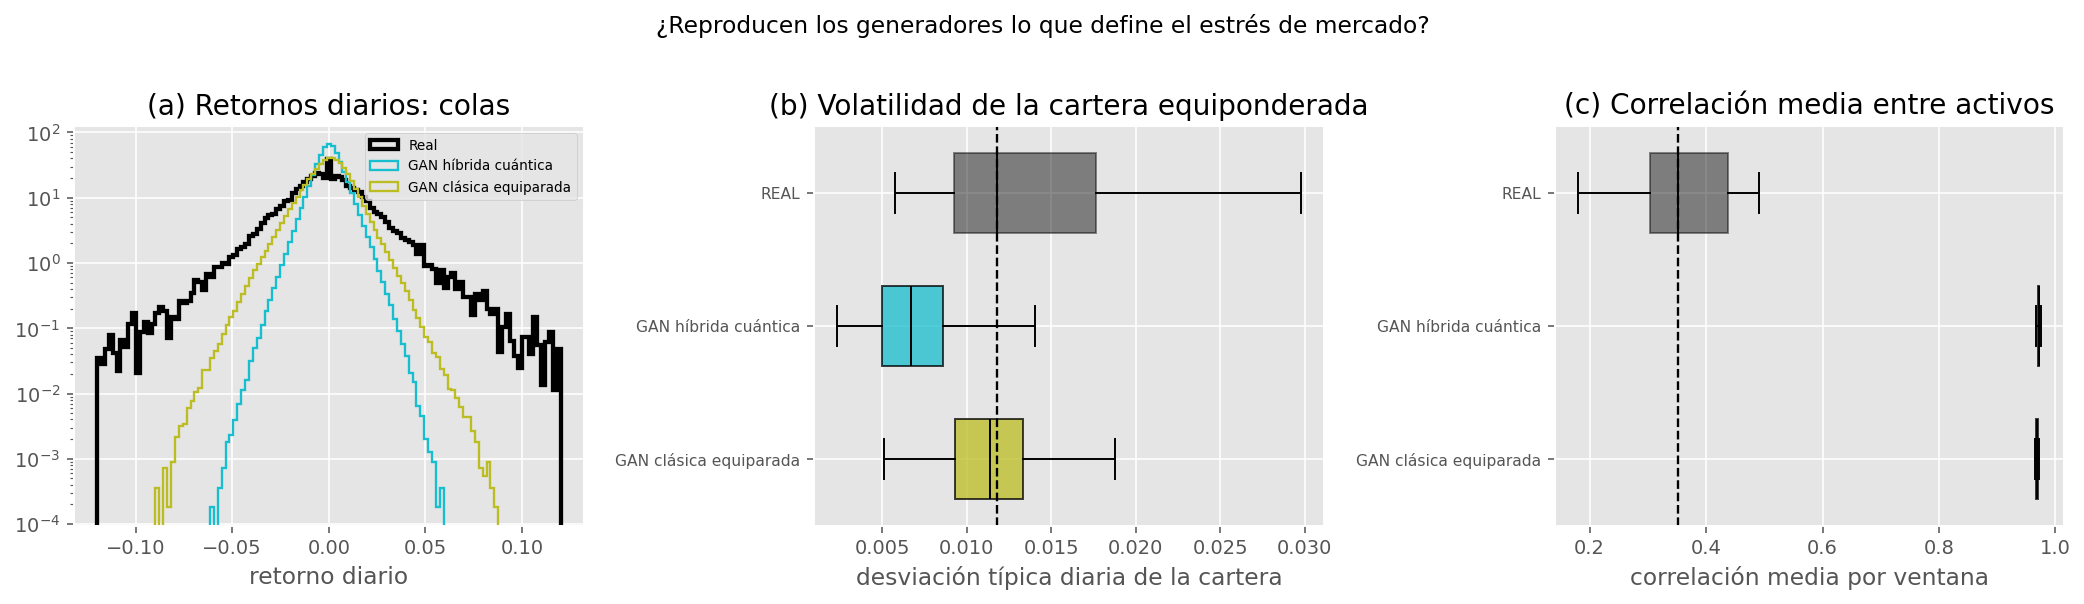

In [7]:
fig = plots.plot_distribution_diagnostics(X_min, sinteticos, name="06_diagnostico_cuantico")
display(Image(str(fig)))

## Evaluación downstream

La única comparación que de verdad importa, y con el mismo protocolo que el barrido: añadir las ventanas sintéticas
a un conjunto real escaso, entrenar la arquitectura congelada y medir en test real.

In [8]:
from src import downstream
from src.sweep import build_training_set, subsample_real

filas = {}
for etiqueta, pool in [("Sin sintéticos", None)] + [
    (plots.GEN_LABELS.get(k, k), v) for k, v in sinteticos.items()
]:
    prs = []
    for seed in (0, 1, 2):
        rng = np.random.default_rng(1000 * seed + 500)
        X_real, y_real = subsample_real(split.X_train, split.y_train, 500, rng)
        X_tr, y_tr = build_training_set(X_real, y_real, pool, 0 if pool is None else 500)
        modelo, _ = downstream.train_classifier(X_tr, y_tr, split.X_val, split.y_val, seed=seed)
        _, m_test, _ = downstream.evaluate_model(
            modelo, split.X_val, split.y_val, split.X_test, split.y_test
        )
        prs.append(m_test.pr_auc)
    filas[etiqueta] = {"test_pr_auc_medio": np.mean(prs), "sem": np.std(prs) / np.sqrt(len(prs))}
    print(f"{etiqueta:45s} PR-AUC = {np.mean(prs):.3f}")
display(pd.DataFrame(filas).T.round(4))

Sin sintéticos                                PR-AUC = 0.480


GAN híbrida cuántica                          PR-AUC = 0.300


GAN clásica equiparada                        PR-AUC = 0.433


,test_pr_auc_medio,sem
Sin sintéticos,0.4803,0.0066
GAN híbrida cuántica,0.2995,0.0324
GAN clásica equiparada,0.4332,0.0060


## Conclusión del bonus

**El resultado es negativo para los dos, y más para el cuántico.** Partiendo de 0,480 de PR-AUC sin sintéticos,
añadir 500 ventanas del gemelo clásico baja a 0,433 y añadir las del cuántico baja a 0,300. Ninguno de los dos
aporta; los dos estorban.

Y la explicación no está en el generador, está una fila más arriba en la tabla de calidad: el **techo del espacio
PCA-16**. El error de reconstrucción de proyectar los datos reales a 16 dimensiones y volver es **0,011**, del mismo
orden que la magnitud típica de un retorno diario (0,0118). Es decir, antes de que ningún generador haga nada, el
espacio ya ha destruido casi toda la información. Cualquier muestra generada ahí, por buena que sea *dentro* del
espacio, vuelve al dominio original como una ventana irreconocible. Es exactamente el hallazgo del notebook 01
llevado al extremo: los retornos diarios no se comprimen.

Lo que sí se puede afirmar:

- el circuito variacional **entrena de verdad**: su pérdida se mueve, ambas pérdidas se mantienen en valores
  intermedios y el generador aprende una distribución no trivial con 72 parámetros variacionales. La parte cuántica
  es real y entrenable, no decorativa;
- la comparación está **bien construida**: 216 parámetros exactos en los dos casos, mismo espacio, mismo
  discriminador, mismas semillas. Cualquier diferencia es atribuible a la familia del generador, no a la capacidad;
- el cuántico es **34 veces más lento** (44,6 s frente a 1,3 s) para el mismo número de parámetros, que es el coste
  esperable de simular un circuito en un ordenador clásico.

### El bonus valida la regla del notebook 05

Hay un detalle que conviene no pasar por alto, porque es una comprobación **fuera de muestra** del resultado
principal del trabajo. En el notebook 05 concluimos que la ganancia downstream la predice la fidelidad en la
volatilidad de cartera. Ordenamos aquí los tres generadores relevantes (los dos del bonus más el factor de
mercado + idio del barrido, que es la referencia de fidelidad alta) por esa magnitud y aplicamos la regla como
predicción:

| | Volatilidad de cartera | Distancia a la real (0,0147) | Predicción de la regla | PR-AUC observado |
|---|---|---|---|---|
| Factor de mercado + idio (barrido) | ~0,0147 | ~0 | mejor referencia | ver notebook 04 |
| GAN clásica equiparada | 0,0114 | 0,0033 | intermedio | **0,433** |
| GAN híbrida cuántica | 0,0070 | 0,0077 | peor de los tres | **0,300** |

**La regla acierta el orden.** Reproducir mejor la volatilidad de cartera se traduce en mejor ganancia downstream:
el factor de mercado (fidelidad ≈ 1) va a la cabeza, la GAN clásica queda en el medio, y la GAN cuántica —que
reproduce peor la magnitud— cierra. No es una demostración con tres puntos, pero es la clase de comprobación
fuera de muestra que da confianza en que la correlación del notebook 05 describe un mecanismo real y no una
coincidencia entre los generadores del barrido.

Lo que **no** se puede afirmar: que el paradigma clásico sea superior al cuántico. Con 8 qubits, un espacio de 16
dimensiones cuyo techo ya es prohibitivo y un test con ~5 episodios independientes, la diferencia entre 0,433 y
0,300 no soporta esa conclusión. Lo honesto es decir que **en este espacio el experimento no puede distinguirlos**,
y que la vía para hacerlo sería primero encontrar una representación de baja dimensión que no destruya la
información, que es un problema abierto para retornos diarios.

Dicho de otro modo: lo valioso del bonus no es quién gana, es haber construido una comparación en la que la
pregunta *se podría* responder, y haber identificado qué hay que arreglar antes.